In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
%matplotlib inline

%load_ext autoreload
%autoreload 2

from waxa import atomdata
from waxa.plotting.plotting_2d import mixOD_grid

font = 'DejaVu Sans'
# font = 'Helvetica Neue'
plt.rcParams['figure.dpi'] = 200
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font]
plt.rcParams['mathtext.fontset'] = 'custom'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
ad = atomdata(0)

64992
[atomdata timing] load total=0.638s | get_data_file(initial)=0.090s | h5_open=0.002s | headers=0.034s | core_arrays=0.509s | datavault=0.000s | scope_data=0.000s
No ROI saved in run 64992 (cached).
Specify the new ROI.
[atomdata timing] init total=10.734s | load_data=0.638s | setup+roi=7.324s | unshuffle_old=0.000s | initial_analysis=2.772s


<Figure size 1280x960 with 0 Axes>

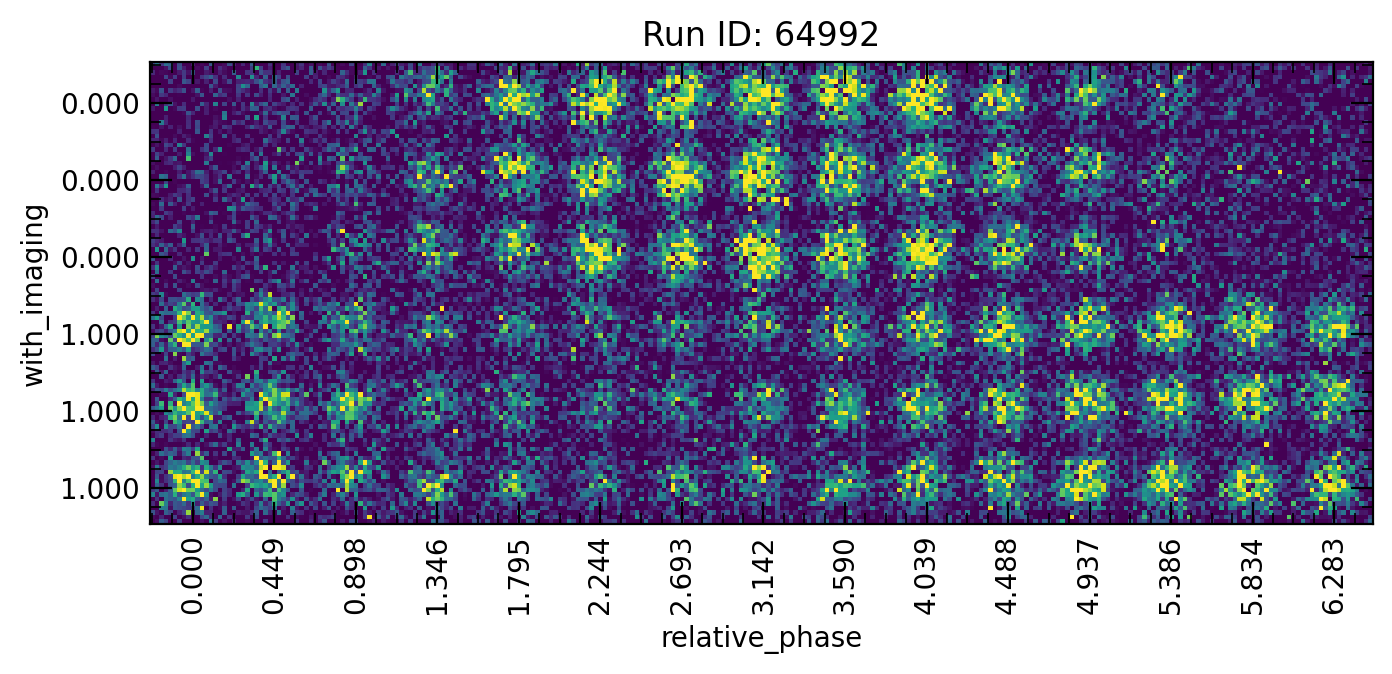

In [13]:
plt.set_cmap("viridis")
mixOD_grid(ad,
           ad.od,
            max_od=2.,
            xvarformat='1.3f',
            figsize=[20,3],
            aspect='equal')
plt.show()

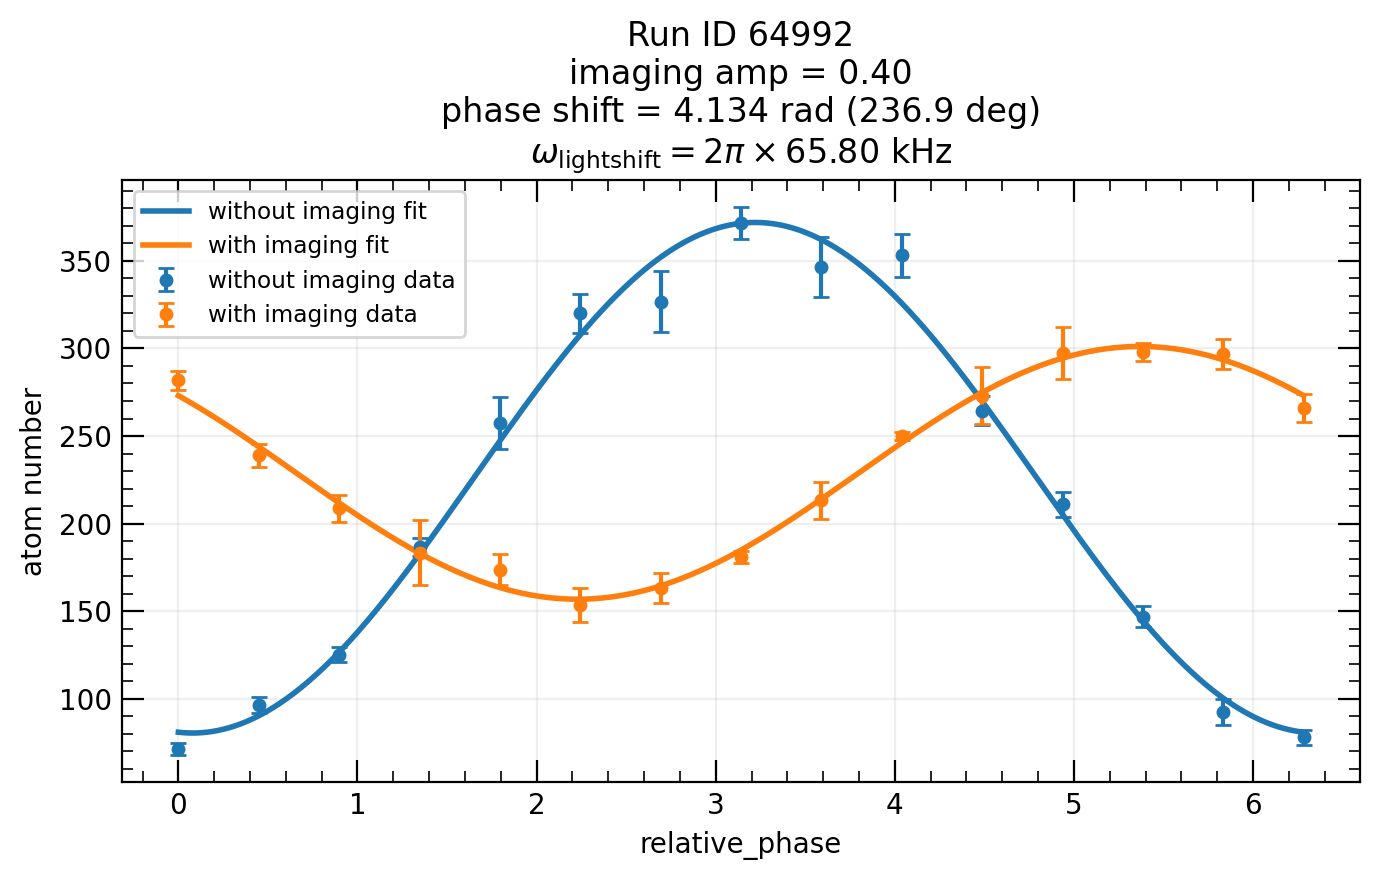

self.p.omega_lightshift = 2 * np.pi * 6.58e+04  # rad/s, for imaging amp 0.4


In [14]:
from scipy.optimize import curve_fit
from kamo import constants as c

xvar0_name = str(ad.xvarnames[0])
xvar1_name = str(ad.xvarnames[1])
xvar0 = np.asarray(ad.xvars[0])
xvar1 = np.asarray(ad.xvars[1], dtype=float)
atom_number = np.asarray(ad.atom_number, dtype=float)

if atom_number.ndim != 2:
    raise ValueError(f"Expected ad.atom_number to be 2D, got shape {atom_number.shape}")
if atom_number.shape[0] != len(xvar0):
    raise ValueError(
        f"Expected len(ad.xvars[0]) == ad.atom_number.shape[0], got {len(xvar0)} and {atom_number.shape[0]}"
    )
if atom_number.shape[1] != len(xvar1):
    raise ValueError(
        f"Expected len(ad.xvars[1]) == ad.atom_number.shape[1], got {len(xvar1)} and {atom_number.shape[1]}"
    )

def wrap_phase(phase):
    return phase % (2 * np.pi)

def cosine_model(phase, amplitude, phase_offset, offset):
    return amplitude * np.cos(phase + phase_offset) + offset

def omega_phase_shift(phase_shift, t_imaging_pulse):
    return abs(phase_shift / t_imaging_pulse)

def classify_imaging_state(value):
    if isinstance(value, (bool, np.bool_)):
        return "on" if value else "off"
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        numeric_value = None

    if numeric_value is not None:
        if np.isclose(numeric_value, 0):
            return "off"
        if np.isclose(numeric_value, 1):
            return "on"

    value_str = str(value).strip().lower()
    if value_str in {"0", "off", "false", "no"}:
        return "off"
    if value_str in {"1", "on", "true", "yes"}:
        return "on"
    return None

def format_group_label(value):
    state = classify_imaging_state(value)
    if state == "off":
        return "without imaging"
    if state == "on":
        return "with imaging"
    return f"{xvar0_name} = {value}"

def fit_trace(phase_values, signal_values):
    valid = np.isfinite(phase_values) & np.isfinite(signal_values)
    x_fit = phase_values[valid]
    y_fit = signal_values[valid]

    amplitude_guess = 0.5 * (np.nanmax(y_fit) - np.nanmin(y_fit))
    offset_guess = np.nanmean(y_fit)
    phase_guess = -x_fit[np.nanargmax(y_fit)]
    popt, pcov = curve_fit(
        cosine_model,
        x_fit,
        y_fit,
        p0=[amplitude_guess, phase_guess, offset_guess],
        maxfev=20000,
    )

    amplitude_fit, phase_fit, offset_fit = popt
    if amplitude_fit < 0:
        amplitude_fit = -amplitude_fit
        phase_fit += np.pi

    popt = np.array([amplitude_fit, wrap_phase(phase_fit), offset_fit])
    return popt, pcov

ordered_xvar0_values = list(dict.fromkeys(xvar0.tolist()))
if len(ordered_xvar0_values) != 2:
    raise ValueError(f"Expected exactly two {xvar0_name} groups, found {ordered_xvar0_values}")

group_results = []
for value in ordered_xvar0_values:
    group_mask = xvar0 == value
    group_data = atom_number[group_mask]
    group_mean = np.nanmean(group_data, axis=0)
    valid_counts = np.sum(np.isfinite(group_data), axis=0)
    group_sem = np.zeros_like(group_mean)
    repeated_points = valid_counts > 1
    if np.any(repeated_points):
        group_sem[repeated_points] = (
            np.nanstd(group_data[:, repeated_points], axis=0, ddof=1)
            / np.sqrt(valid_counts[repeated_points])
        )
    fit_params, fit_cov = fit_trace(xvar1, group_mean)

    group_results.append({
        "value": value,
        "state": classify_imaging_state(value),
        "label": format_group_label(value),
        "mean": group_mean,
        "sem": group_sem,
        "fit_params": fit_params,
        "fit_cov": fit_cov,
    })

state_priority = {"off": 0, "on": 1, None: 2}
group_results.sort(key=lambda item: state_priority.get(item["state"], 2))

phase_grid = np.linspace(np.nanmin(xvar1), np.nanmax(xvar1), 1000)
color_map = {"off": "tab:blue", "on": "tab:orange", None: "tab:green"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for result in group_results:
    color = color_map.get(result["state"], "tab:green")
    ax.errorbar(
        xvar1,
        result["mean"],
        yerr=result["sem"],
        fmt="o",
        ms=4,
        capsize=3,
        color=color,
        label=f"{result['label']} data",
    )
    ax.plot(
        phase_grid,
        cosine_model(phase_grid, *result["fit_params"]),
        color=color,
        lw=2,
        label=f"{result['label']} fit",
    )

phase_by_state = {result["state"]: result["fit_params"][1] for result in group_results}
if "off" in phase_by_state and "on" in phase_by_state:
    phase_shift = (phase_by_state["on"] - phase_by_state["off"]) % (2 * np.pi)
else:
    phase_shift = (group_results[1]["fit_params"][1] - group_results[0]["fit_params"][1]) % (2 * np.pi)

def omega_phase_shift(phase_shift, t_imaging_pulse):
    return abs(phase_shift / t_imaging_pulse)
f_lightshift = omega_phase_shift(phase_shift, t_imaging_pulse=ad.p.t_ramsey) / (2 * np.pi)

ax.set_xlabel(xvar1_name)
ax.set_ylabel("atom number")
ax.set_title(
    f"Run ID {ad.run_info.run_id}\n"
    f"imaging amp = {ad.p.amp_imaging:1.2f}\n"
    f"phase shift = {phase_shift:.3f} rad ({np.degrees(phase_shift):.1f} deg)\n"
    f"$\\omega_\\text{{lightshift}} = 2 \\pi \\times {f_lightshift/1.e3:1.2f}$ kHz"
)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'self.p.omega_lightshift = 2 * np.pi * {f_lightshift:.3g}  # rad/s, for imaging amp {ad.p.amp_imaging}')

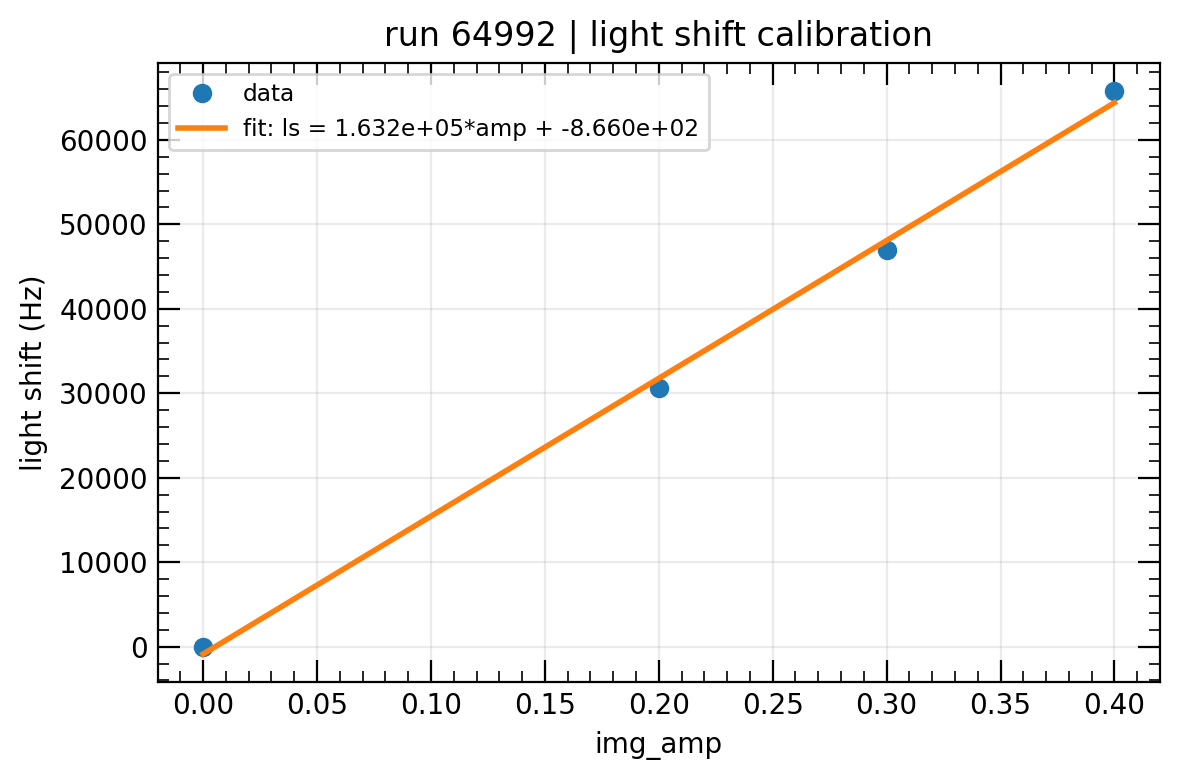

slope = 163160 Hz/amp, intercept = -866 Hz


In [15]:
img_amps = [0.0, 0.2, 0.3, 0.4]
ls = [0.,30.57e3,47.01e3,65.8e3]

img_amps_arr = np.asarray(img_amps, dtype=float)
ls_arr = np.asarray(ls, dtype=float)

slope, intercept = np.polyfit(img_amps_arr, ls_arr, 1)

x_fit = np.linspace(img_amps_arr.min(), img_amps_arr.max(), 300)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(img_amps_arr, ls_arr, "o", ms=6, label="data")
ax.plot(x_fit, y_fit, "-", lw=2, label=f"fit: ls = {slope:.3e}*amp + {intercept:.3e}")
ax.set_xlabel("img_amp")
ax.set_ylabel("light shift (Hz)")
ax.set_title(f"run {ad.run_info.run_id} | light shift calibration")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

def ls_from_img_amp(img_amp):
    img_amp = np.asarray(img_amp, dtype=float)
    ls_val = slope * img_amp + intercept
    return ls_val.item() if ls_val.ndim == 0 else ls_val

print(f"slope = {slope:.6g} Hz/amp, intercept = {intercept:.6g} Hz")

In [17]:
img_amps = np.linspace(.4,2.5,30)
lss = ls_from_img_amp(img_amps)

In [18]:
119.4639e6 + lss

array([1.19528298e+08, 1.19540113e+08, 1.19551928e+08, 1.19563743e+08,
       1.19575558e+08, 1.19587373e+08, 1.19599188e+08, 1.19611003e+08,
       1.19622818e+08, 1.19634633e+08, 1.19646448e+08, 1.19658263e+08,
       1.19670078e+08, 1.19681893e+08, 1.19693708e+08, 1.19705524e+08,
       1.19717339e+08, 1.19729154e+08, 1.19740969e+08, 1.19752784e+08,
       1.19764599e+08, 1.19776414e+08, 1.19788229e+08, 1.19800044e+08,
       1.19811859e+08, 1.19823674e+08, 1.19835489e+08, 1.19847304e+08,
       1.19859119e+08, 1.19870934e+08])